In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [8]:
from langchain_openai import ChatOpenAI 

llm= ChatOpenAI(model="gpt-4o")
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-Bl9kwGNF7wWQztzMeJwl3RJQi7M0S', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--18c07d8d-deb2-45ad-a2e5-a6a6e21440ce-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
from langgraph.types import Command

In [12]:
from langgraph.prebuilt import create_react_agent

In [15]:
def add_number(state):
    result= state["num1"] + state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply", update={"sum":result})

In [18]:
state= {"num1": 10, "num2": 20}
state

{'num1': 10, 'num2': 20}

In [19]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

### Creating one dummy multiagent

It is for network/collabrating multiagent.

In [20]:
from langchain_core.tools import tool

In [23]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    
    return

In [24]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    
    return

In [35]:
llm_with_tool= llm.bind_tools([transfer_to_addition_expert])

In [27]:
response= llm_with_tool.invoke("Hi")
response.content

'Hello! How can I assist you today?'

In [28]:
response.tool_calls

[]

In [36]:
response= llm_with_tool.invoke("what is 2+2?")
response.content

''

In [37]:
response.tool_calls 

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_Bcmb26JbDCOyIWsFa8qXSRrW',
  'type': 'tool_call'}]

In [135]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [78]:
system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [79]:
messages= [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [80]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [71]:
# Agent1 
def additional_expert(state: MessagesState) -> Command[Literal["multiplication_expert", "__end__"]]:
    system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id= ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [70]:
# Agent2
def multiplication_expert(state: MessagesState) -> Command[Literal["additional_expert", "__end__"]]:
    system_prompt= (
        "You are a multiplication expert, you can ask an addition expert for help with addition."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_addition_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]}) 
    return {"messages": [ai_msg]}

In [72]:
graph= StateGraph(MessagesState)

In [73]:
graph.add_node("additional_expert", additional_expert)
graph.add_node("multiplication_expert", multiplication_expert)

In [74]:
graph.add_edge(START, "additional_expert")
# graph.add_edge("multiplication_expert", "additional_expert")

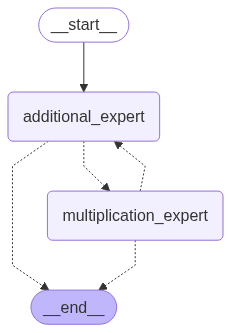

In [60]:
graph.compile()

In [75]:
app= graph.compile()

In [81]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='f373b487-c67c-48b3-b692-5a48f1adc3aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_pKmpZ4baiocYiO6wMj9aFpMq', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 86, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BlBJhPMmF0OatWIweAiO0yKYUDHLn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4b6e29b1-188a-49a9-9b75-9f1c8b916631-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 

### With Realtime tool

In [88]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool= DuckDuckGoSearchRun()
search_tool.invoke("Who is the pm of inda") # We have typo error while invoke but still getting correct result

"List of all Prime Ministers of India till 2025: Narendra Modi is the current and 14th Prime Minister of India who assumed office on 10 June 2024. Jawaharlal Nehru is the first and the longest ... The prime minister of India is the head of government and has the responsibility for executive power. The president's constitutional duty is to preserve, protect and defend the Constitution and the law per article 60. In the constitution of India, the prime minister is mentioned in only four of its articles (articles 74, 75, 78 and 366). The Prime Minister, Shri Narendra Modi addressed the 11th International Day of Yoga (IYD) event in Visakhapatnam, Andhra Pradesh today. ... Shri Narendra Modi was sworn-in as India's Prime Minister for the third time on 9th June 2024, following another decisive victory in the 2024 Parliamentary elections. This victory marked the third ... The list of Indian Prime Ministers begins with Jawaharlal Nehru, who became the first Prime Minister in 1947 and consist .

In [99]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

TAVILY_API_KEY= os.getenv("TAVILY_API_KEY")

search_tool= TavilySearchResults(tavily_api_key=TAVILY_API_KEY)
search_tool.invoke("Who is the pm of inda") # We have typo error while invoke but still getting correct result

[{'title': 'Prime Minister of India - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Prime_Minister_of_India',
  'content': 'Rao](https://en.wikipedia.org/wiki/P._V._Narasimha_Rao "P. V. Narasimha Rao"), [Atal Bihari Vajpayee](https://en.wikipedia.org/wiki/Atal_Bihari_Vajpayee "Atal Bihari Vajpayee"), [Manmohan Singh](https://en.wikipedia.org/wiki/Manmohan_Singh "Manmohan Singh"), and [Narendra Modi. Modi](https://en.wikipedia.org/wiki/Narendra_Modi "Narendra Modi") is the current prime minister of India, serving since [26 May 2014](https://en.wikipedia.org/wiki/First_swearing-in_ceremony_of_Narendra_Modi "First [...] The **prime minister of India** ([ISO](https://en.wikipedia.org/wiki/ISO_15919 "ISO 15919"): _Bhārata kē Pradhānamantrī_) is the [head of government](https://en.wikipedia.org/wiki/Head_of_government "Head of government")[[2]](https://en.wikipedia.org/wiki/Prime_Minister_of_India#cite_note-2) of the [Republic of India](https://en.wikipedia.org/wiki/Republic_of_India "

In [100]:
search_tool.invoke("who is a current pm of uk?")

[{'title': 'Rishi Sunak - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Rishi_Sunak',
  'content': '| [The Right Honourable](/wiki/The_Right_Honourable "The Right Honourable")  Rishi Sunak  [MP](/wiki/Member_of_Parliament_(United_Kingdom) "Member of Parliament (United Kingdom)") | |\n| --- | --- |\n| [Rishi Sunak](/wiki/File:Portrait_of_Prime_Minister_Rishi_Sunak_(cropped).jpg) Official portrait, 2022 | |\n|  | |\n| [Prime Minister of the United Kingdom](/wiki/Prime_Minister_of_the_United_Kingdom "Prime Minister of the United Kingdom") | |\n| **In office** 25 October 2022\xa0– 5 July 2024 | | [...] | Ministerial portfolios 2018\u200d–\u200d2022 | |\n| --- | --- |\n|  | |\n| [Chancellor of the Exchequer](/wiki/Chancellor_of_the_Exchequer "Chancellor of the Exchequer") | |\n| **In office** 13 February 2020\xa0– 5 July 2022 | |\n| Prime Minister | [Boris Johnson](/wiki/Boris_Johnson "Boris Johnson") |\n| Preceded by | [Sajid Javid](/wiki/Sajid_Javid "Sajid Javid") |\n| Succeeded by 

In [93]:
from langchain_experimental.utilities import PythonREPL

In [94]:
repl= PythonREPL()

In [97]:
code = """
x = 5
y = x * 2
print(y)
"""

In [98]:
repl.run(code)

'10\n'

In [102]:
from typing import Annotated

In [110]:
from langchain_core.tools import tool

In [124]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    
    """
    Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.
    """
    try:
        result= repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    # result_str= f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}
    result_str= f"Successfully executed:\n python\n{code}\n\nStdout: {result}"
    
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [125]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\nyou should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x0000025058C353A0>)

In [126]:
print(python_repl_tool.invoke(code))

Successfully executed:
 python

x = 5
y = x * 2
print(y)


Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [128]:
code="""import matplotlib.pyplot as plt\\n\\n# Data for the UK GDP over the past 3 years\\nyears = [2019, 2020, 2021]\\ngdp_values = [2851.41, 2697.81, 3141.51]  # in billion $ \\n\\ndef create_line_chart(years, gdp_values):\\n    plt.figure(figsize=(10, 6))\\n    plt.plot(years, gdp_values, marker=\'o\', color=\'b\', linestyle=\'-\', linewidth=2)\\n    plt.title(\'UK GDP Over the Past 3 Years\')\\n    plt.xlabel(\'Year\')\\n    plt.ylabel(\'GDP (in billion $)\')\\n    plt.grid(True)\\n    plt.tight_layout()\\n    plt.show()"""

In [129]:
print(python_repl_tool.invoke(code))

Successfully executed:
 python
import matplotlib.pyplot as plt\n\n# Data for the UK GDP over the past 3 years\nyears = [2019, 2020, 2021]\ngdp_values = [2851.41, 2697.81, 3141.51]  # in billion $ \n\ndef create_line_chart(years, gdp_values):\n    plt.figure(figsize=(10, 6))\n    plt.plot(years, gdp_values, marker='o', color='b', linestyle='-', linewidth=2)\n    plt.title('UK GDP Over the Past 3 Years')\n    plt.xlabel('Year')\n    plt.ylabel('GDP (in billion $)')\n    plt.grid(True)\n    plt.tight_layout()\n    plt.show()

Stdout: SyntaxError('unexpected character after line continuation character', ('<string>', 1, 33, "import matplotlib.pyplot as plt\\n\\n# Data for the UK GDP over the past 3 years\\nyears = [2019, 2020, 2021]\\ngdp_values = [2851.41, 2697.81, 3141.51]  # in billion $ \\n\\ndef create_line_chart(years, gdp_values):\\n    plt.figure(figsize=(10, 6))\\n    plt.plot(years, gdp_values, marker='o', color='b', linestyle='-', linewidth=2)\\n    plt.title('UK GDP Over the Pas

In [170]:
def make_system_prompt(instruction: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [171]:
make_system_prompt("You can only do research. You are working with a chart generator colleague.")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [133]:
from langchain_core.messages import BaseMessage, HumanMessage

In [172]:
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [137]:
from langgraph.graph import END

In [173]:
#agent1
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    research_agent= create_react_agent(
        llm,
        tools= [search_tool],
        prompt= make_system_prompt(
            "You can only do research. You are working with a chart generator colleague.",
        )
    )
    
    result= research_agent.invoke(state)
    goto= get_next_node(result["messages"][-1], "chart_generator")
    result["messages"][-1]= HumanMessage(content=result["messages"][-1].content, name="researcher")

    return Command(update={"messages": result["messages"]}, goto=goto)

In [174]:
#agent2
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    chart_agent= create_react_agent(
        llm,
        tools= [python_repl_tool],
        prompt= make_system_prompt(
            "You can only generate charts. You are working with a researcher colleague.",
        )
    )

    result= chart_agent.invoke(state)
    goto= get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1]= HumanMessage(content=result["messages"][-1].content, name="chart_generator")

    return Command(update={"messages": result["messages"]}, goto=goto)

In [175]:
workflow = StateGraph(MessagesState)

workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")

app = workflow.compile()

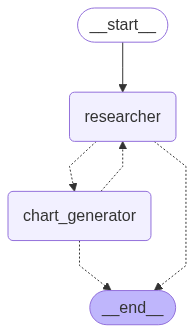

In [151]:
workflow.compile()

In [177]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='55fa0173-093d-400c-9cb6-b7f83ecbb9f7'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_LF8cWdKckqBzgn8oWxWdALZ6', 'function': {'arguments': '{"query":"UK GDP past 3 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 205, 'total_tokens': 228, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BlD3ca93Ap34F9xAc7KAdjwvSH7vE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b993ce3d-66e6-47a